# Principal Components Analysis (PCA)

## Real-World Scenario: Discovering Latent Cell States from Gene Expression

In whole cell modeling, we measure the expression of thousands of genes across many single cells. Each cell becomes a point $\mathbf{x} \in \mathbb{R}^D$ in a very high-dimensional gene-expression space, but the *effective* number of degrees of freedom is far smaller: cells differ along a handful of biological axes such as **cell-cycle phase**, **metabolic activity**, and **stress response**. Many genes are co-regulated through shared transcription-factor pathways, so their expression varies together.

PCA finds those hidden axes. It learns a linear, orthogonal projection $\mathbf{z} = \mathbf{W}^\top \mathbf{x}$ onto a low-dimensional subspace $\mathbf{z} \in \mathbb{R}^L$ such that the reconstruction $\hat{\mathbf{x}} = \mathbf{W}\mathbf{z}$ is as close as possible to the original expression vector. The columns of $\mathbf{W}$ — the principal directions — capture the dominant patterns of co-variation between genes.

We work through:

1. **Reconstruction error** as the PCA objective
2. **Base case**: deriving the first principal direction
3. **Maximum-variance interpretation** of PCA
4. **Induction step**: orthogonal extra components
5. **Computational issues**: covariance vs correlation matrix, SVD
6. **Choosing $L$**: reconstruction error, scree plot, profile likelihood

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import norm

np.random.seed(0)
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'

## Key Formulas from PML Chapter 20.1

**Reconstruction loss** (Eq. 20.1, 20.3):

$$\mathcal{L}(\mathbf{W}) = \frac{1}{N} \sum_{n=1}^{N} \|\mathbf{x}_n - \mathbf{W}\mathbf{z}_n\|_2^2, \qquad \mathbf{z}_n = \mathbf{W}^\top \mathbf{x}_n$$

**Empirical covariance matrix** of centered data (Eq. 20.2):

$$\hat{\boldsymbol{\Sigma}} = \frac{1}{N} \sum_{n=1}^{N} (\mathbf{x}_n - \bar{\mathbf{x}})(\mathbf{x}_n - \bar{\mathbf{x}})^\top$$

**Optimal first direction** as eigenvector of $\hat{\boldsymbol{\Sigma}}$ (Eq. 20.12):

$$\hat{\boldsymbol{\Sigma}}\, \mathbf{w}_1 = \lambda_1\, \mathbf{w}_1$$

**Variance of the projection** (Eq. 20.13–20.16):

$$\mathbb{V}[z_1] = \mathbf{w}_1^\top \hat{\boldsymbol{\Sigma}} \mathbf{w}_1 = \lambda_1 \quad \Rightarrow \quad \arg\min_{\mathbf{w}_1} \mathcal{L}(\mathbf{w}_1) = \arg\max_{\mathbf{w}_1} \mathbb{V}[z_1]$$

**SVD route to PCA** (Eq. 20.23–20.24): if $\mathbf{X} = \mathbf{U}_X \mathbf{S}_X \mathbf{V}_X^\top$ then $\mathbf{W} = \mathbf{V}_X$, $\mathbf{Z} = \mathbf{U}_X \mathbf{S}_X$, $\hat{\mathbf{X}} = \mathbf{U}_X \mathbf{S}_X \mathbf{V}_X^\top$.

**Reconstruction error in terms of discarded eigenvalues** (Eq. 20.26):

$$\mathcal{L}_L = \sum_{j=L+1}^{D} \lambda_j$$

**Fraction of variance explained** (Eq. 20.27):

$$F_L = \frac{\sum_{j=1}^{L} \lambda_j}{\sum_{j'=1}^{L^{\max}} \lambda_{j'}}$$

**Profile log-likelihood** (Eq. 20.31): a change-point model on the eigenvalue sequence to detect the elbow.

## 1. Synthetic Single-Cell Gene Expression Data

We simulate $N = 400$ cells across $D = 50$ genes from three phenotypes — **High Growth**, **Stress Response**, and **Quiescent**. Two latent biological factors drive expression (a growth axis and a stress axis); the remaining 48 dimensions arise from random co-regulation patterns plus measurement noise. This gives a low-rank ground truth that PCA should be able to recover.

In [3]:
N_per = 130
C = 3
D = 50
L_true = 2
N = N_per * C

phenotype_names = ['High Growth', 'Stress Response', 'Quiescent']
phenotype_colors = ['#2ca02c', '#d62728', '#1f77b4']

# Latent centers (in 2D latent space): growth axis vs stress axis
true_centers = np.array([
    [ 3.0,  0.0],   # High growth
    [-1.5,  2.5],   # Stress response
    [-1.5, -2.5],   # Quiescent
])

# Sample latent factors per cell
Z_true = np.vstack([
    true_centers[c] + 0.6 * np.random.randn(N_per, L_true)
    for c in range(C)
])
y = np.repeat(np.arange(C), N_per)

# Random orthonormal gene-loading matrix (D x L_true)
W_true, _ = np.linalg.qr(np.random.randn(D, L_true))

# Generate gene expression with measurement noise + a baseline mean per gene
noise_std = 0.35
baseline = 2.0 + 0.5 * np.random.randn(D)
X = Z_true @ W_true.T + noise_std * np.random.randn(N, D) + baseline

# Shuffle
perm = np.random.permutation(N)
X, y, Z_true = X[perm], y[perm], Z_true[perm]

print(f'Data shape: {X.shape}  (N={N} cells, D={D} genes)')
print(f'Phenotypes: {dict(zip(phenotype_names, [int((y==c).sum()) for c in range(C)]))}')
print(f'True latent dimensionality: {L_true}')

Data shape: (390, 50)  (N=390 cells, D=50 genes)
Phenotypes: {'High Growth': 130, 'Stress Response': 130, 'Quiescent': 130}
True latent dimensionality: 2


## 2. Centering and the Empirical Covariance Matrix

PCA requires centered data: $\bar{\mathbf{x}} = \frac{1}{N} \sum_n \mathbf{x}_n = \mathbf{0}$. We compute the empirical covariance $\hat{\boldsymbol{\Sigma}} = \frac{1}{N} \mathbf{X}_c^\top \mathbf{X}_c$ and visualise its block structure: groups of co-regulated genes show up as off-diagonal blocks.

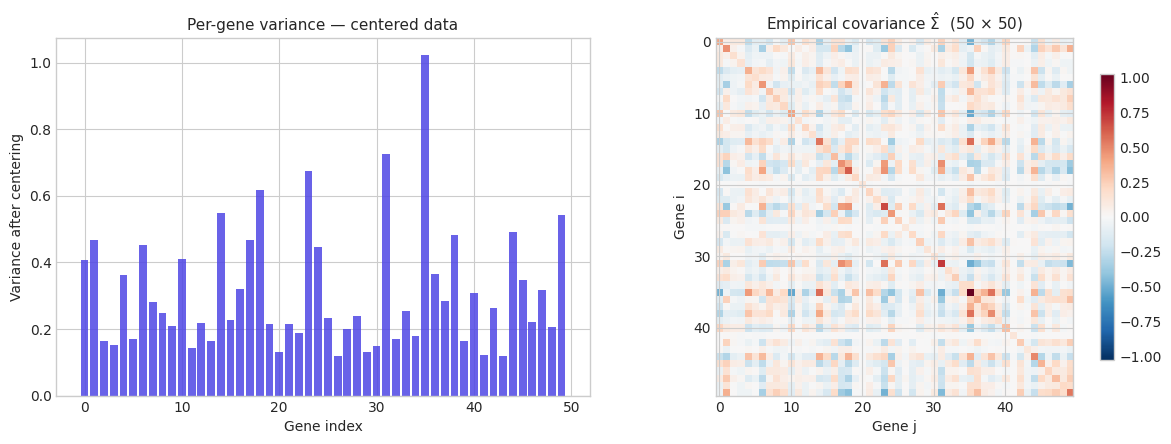

mean(x) after centering ≈ 3.55e-15
Trace(Sigma) = total variance = 15.550


In [4]:
x_mean = X.mean(axis=0)
Xc = X - x_mean
Sigma_hat = (Xc.T @ Xc) / N

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Per-gene mean and variance
ax = axes[0]
ax.bar(np.arange(D), Xc.var(axis=0), color='#4f46e5', alpha=0.85)
ax.set_xlabel('Gene index')
ax.set_ylabel('Variance after centering')
ax.set_title('Per-gene variance — centered data', fontsize=11)

# Empirical covariance matrix
ax = axes[1]
vmax = np.abs(Sigma_hat).max()
im = ax.imshow(Sigma_hat, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.set_title(r'Empirical covariance $\hat{\Sigma}$  (50 × 50)', fontsize=11)
ax.set_xlabel('Gene j'); ax.set_ylabel('Gene i')
plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout(); plt.show()

print(f'mean(x) after centering ≈ {np.abs(Xc.mean(axis=0)).max():.2e}')
print(f'Trace(Sigma) = total variance = {np.trace(Sigma_hat):.3f}')

## 3. Base Case: The First Principal Direction Maximises Variance

Following Section 20.1.2.1, we solve

$$\mathbf{w}_1 = \arg\min_{\|\mathbf{w}\|=1}\; \frac{1}{N}\sum_n \|\mathbf{x}_n - z_{n1} \mathbf{w}\|^2 = \arg\max_{\|\mathbf{w}\|=1}\; \mathbf{w}^\top \hat{\boldsymbol{\Sigma}} \mathbf{w}$$

Setting derivatives to zero with a Lagrange multiplier yields $\hat{\boldsymbol{\Sigma}}\mathbf{w}_1 = \lambda_1 \mathbf{w}_1$, so $\mathbf{w}_1$ is the top eigenvector of $\hat{\boldsymbol{\Sigma}}$ and the projected variance equals $\lambda_1$. Let's verify numerically by sweeping a unit vector $\mathbf{w}(\theta)$ through 2D and plotting both the reconstruction loss and the projected variance against $\theta$.

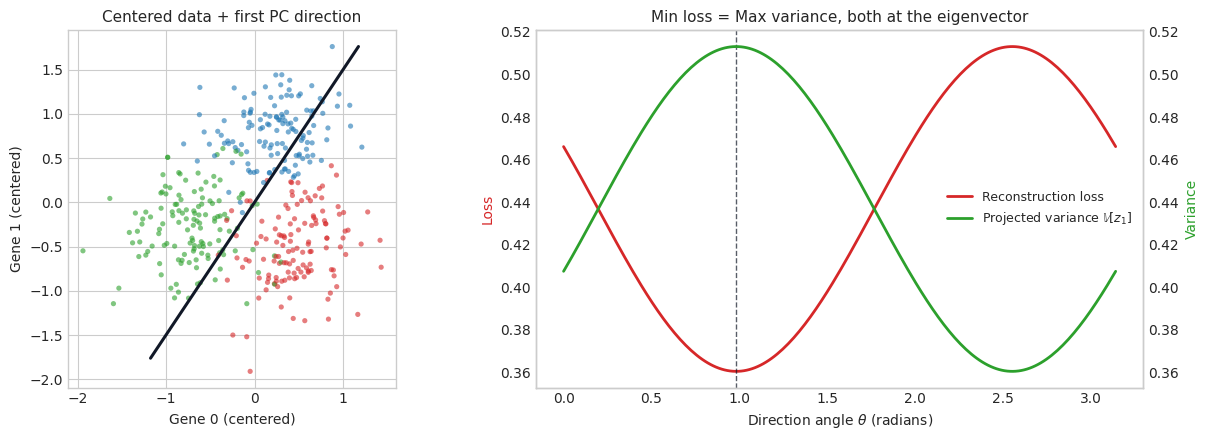

Argmax variance at θ = 0.979  rad
Argmin loss     at θ = 0.979  rad
Top-eigenvector at θ = 0.982  rad
λ_1 = projected variance at optimum = 0.5131


In [5]:
# Restrict to 2 genes for a 2D visualization of the variance/loss landscape
X2 = Xc[:, :2]
Sigma2 = (X2.T @ X2) / N

thetas = np.linspace(0, np.pi, 200)
loss = np.empty_like(thetas)
var_proj = np.empty_like(thetas)

for i, th in enumerate(thetas):
    w = np.array([np.cos(th), np.sin(th)])
    z = X2 @ w                   # projection scores
    var_proj[i] = z.var()
    loss[i] = ((X2 - np.outer(z, w))**2).sum(axis=1).mean()

# True top eigenvector of Sigma2
evals2, evecs2 = np.linalg.eigh(Sigma2)
w1_true = evecs2[:, -1]
theta_star = np.arctan2(w1_true[1], w1_true[0]) % np.pi

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.scatter(X2[:, 0], X2[:, 1], c=[phenotype_colors[c] for c in y],
           s=14, alpha=0.6, edgecolor='none')
scale = 3 * np.sqrt(evals2[-1])
ax.annotate('', xy=(scale*w1_true[0], scale*w1_true[1]),
            xytext=(-scale*w1_true[0], -scale*w1_true[1]),
            arrowprops=dict(arrowstyle='-', color='#111827', lw=2.2))
ax.set_xlabel('Gene 0 (centered)'); ax.set_ylabel('Gene 1 (centered)')
ax.set_title('Centered data + first PC direction', fontsize=11)
ax.set_aspect('equal')

ax = axes[1]
ax2 = ax.twinx()
l1, = ax.plot(thetas, loss, color='#d62728', lw=2, label='Reconstruction loss')
l2, = ax2.plot(thetas, var_proj, color='#2ca02c', lw=2, label=r'Projected variance $\mathbb{V}[z_1]$')
ax.axvline(theta_star, color='#111827', ls='--', lw=1, alpha=0.7)
ax.set_xlabel(r'Direction angle $\theta$ (radians)')
ax.set_ylabel('Loss', color='#d62728')
ax2.set_ylabel('Variance', color='#2ca02c')
ax.set_title('Min loss = Max variance, both at the eigenvector', fontsize=11)
ax.legend(handles=[l1, l2], loc='center right', fontsize=9)
ax.grid(False); ax2.grid(False)

plt.tight_layout(); plt.show()

print(f'Argmax variance at θ = {thetas[var_proj.argmax()]:.3f}  rad')
print(f'Argmin loss     at θ = {thetas[loss.argmin()]:.3f}  rad')
print(f'Top-eigenvector at θ = {theta_star:.3f}  rad')
print(f'λ_1 = projected variance at optimum = {evals2[-1]:.4f}')

In [15]:
w1_true
# evecs2

array([0.55500498, 0.83184703])

All three curves agree: the direction that **minimises reconstruction loss** is exactly the direction that **maximises projected variance**, and it equals the top eigenvector of $\hat{\boldsymbol{\Sigma}}$ — confirming Equations 20.12 and 20.16.

## 4. Induction Step: Multi-Component PCA via Eigendecomposition

The argument generalises (Section 20.1.2.3): subsequent components are the next eigenvectors of $\hat{\boldsymbol{\Sigma}}$ in order of decreasing eigenvalue. We compute the full PCA on the 50-gene data and project the 400 cells onto the top-2 components.

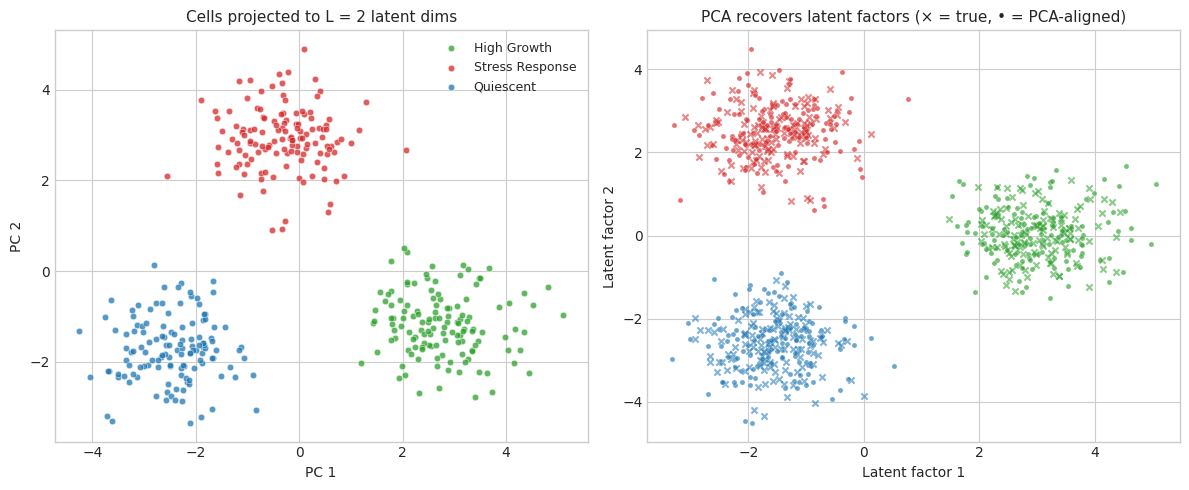

Top 2 eigenvalues: [5.1004 4.7552]
Sum of bottom 48 eigenvalues = predicted recon error = 5.6944
Empirical reconstruction error                            = 5.6944


In [7]:
def pca_eig(X_centered, L):
    """PCA via eigendecomposition of the empirical covariance matrix."""
    N = X_centered.shape[0]
    Sigma = (X_centered.T @ X_centered) / N
    # eigh returns ascending; reverse to descending
    evals, evecs = np.linalg.eigh(Sigma)
    evals = evals[::-1]
    evecs = evecs[:, ::-1]
    W = evecs[:, :L]
    return W, evals

L = 2
W, evals = pca_eig(Xc, L)
Z = Xc @ W                # encode
X_hat_centered = Z @ W.T  # decode (centered)
X_hat = X_hat_centered + x_mean

recon_err = ((Xc - X_hat_centered) ** 2).sum(axis=1).mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Projection onto top 2 PCs
ax = axes[0]
for c in range(C):
    m = y == c
    ax.scatter(Z[m, 0], Z[m, 1], c=phenotype_colors[c],
               s=22, alpha=0.75, edgecolor='white', linewidth=0.4,
               label=phenotype_names[c])
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
ax.set_title('Cells projected to L = 2 latent dims', fontsize=11)
ax.legend(fontsize=9)

# Recovered latent space (Z) vs. true latent factors (Z_true) — up to rotation
# Align via Procrustes for clear visualization
U_, _, Vt_ = np.linalg.svd(Z.T @ Z_true)
R = U_ @ Vt_
Z_aligned = Z @ R

ax = axes[1]
for c in range(C):
    m = y == c
    ax.scatter(Z_true[m, 0], Z_true[m, 1], c=phenotype_colors[c],
               s=20, alpha=0.55, marker='x', label=f'true {phenotype_names[c]}')
    ax.scatter(Z_aligned[m, 0], Z_aligned[m, 1], c=phenotype_colors[c],
               s=14, alpha=0.65, edgecolor='white', linewidth=0.3)
ax.set_xlabel('Latent factor 1'); ax.set_ylabel('Latent factor 2')
ax.set_title('PCA recovers latent factors (× = true, • = PCA-aligned)', fontsize=11)

plt.tight_layout(); plt.show()

print(f'Top {L} eigenvalues: {evals[:L].round(4)}')
print(f'Sum of bottom {D-L} eigenvalues = predicted recon error = {evals[L:].sum():.4f}')
print(f'Empirical reconstruction error                            = {recon_err:.4f}')

PCA recovers a 2D latent structure that, after rotation, matches the ground-truth growth/stress factors. The empirical reconstruction error matches $\sum_{j>L} \lambda_j$ exactly (Eq. 20.26).

## 5. Computing PCA via SVD (Section 20.1.3.3)

Truncated SVD on the centered data matrix gives the same answer with better numerics:

$$\mathbf{X}_c = \mathbf{U}_X \mathbf{S}_X \mathbf{V}_X^\top \quad\Rightarrow\quad \mathbf{W} = \mathbf{V}_X[:,\!:\!L], \quad \mathbf{Z} = \mathbf{U}_X \mathbf{S}_X[:,\!:\!L], \quad \lambda_k = s_k^2 / N$$

In [8]:
U_x, s_x, Vt_x = np.linalg.svd(Xc, full_matrices=False)

W_svd = Vt_x[:L, :].T
Z_svd = U_x[:, :L] * s_x[:L]
evals_svd = (s_x ** 2) / N

# Eigenvectors are unique up to sign; align signs for comparison
sign = np.sign((W * W_svd).sum(axis=0))
W_svd_aligned = W_svd * sign
Z_svd_aligned = Z_svd * sign

print(f'max |W_eig - W_svd|           = {np.abs(W - W_svd_aligned).max():.2e}')
print(f'max |Z_eig - Z_svd|           = {np.abs(Z - Z_svd_aligned).max():.2e}')
print(f'max |λ_eig - s²/N|  (top {L}) = {np.abs(evals[:L] - evals_svd[:L]).max():.2e}')

max |W_eig - W_svd|           = 2.23e-15
max |Z_eig - Z_svd|           = 1.91e-14
max |λ_eig - s²/N|  (top 2) = 3.55e-15


## 6. Standardisation: Covariance vs. Correlation Matrix (Section 20.1.3.1)

When features have wildly different scales, PCA on the raw covariance matrix is dominated by whichever variable happens to use the biggest units. Standardising each feature to zero mean and unit variance is equivalent to running PCA on the **correlation matrix** instead — usually the right thing to do.

We illustrate by inflating one gene's measurement scale 50× (e.g. expressed in a different normalisation unit) and comparing the first principal direction with and without standardisation.

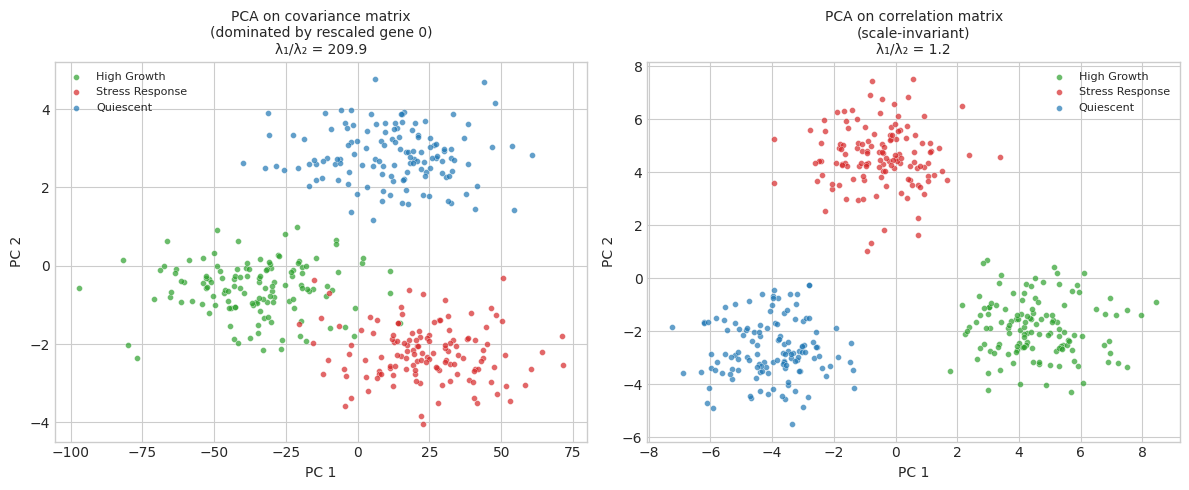

|<w1_raw, e_0>|  = 0.998   (~1 means PC1 ≈ rescaled gene)
|<w1_std, e_0>|  = 0.184   (small means scale-invariant)


In [9]:
X_skew = X.copy()
X_skew[:, 0] *= 50.0   # one gene reported on a wildly different scale
Xc_skew = X_skew - X_skew.mean(axis=0)

# PCA on raw (covariance-based)
W_raw, ev_raw = pca_eig(Xc_skew, L=2)
Z_raw = Xc_skew @ W_raw

# PCA on standardised (correlation-based)
X_std = Xc_skew / Xc_skew.std(axis=0)
W_std, ev_std = pca_eig(X_std, L=2)
Z_std = X_std @ W_std

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, Zp, ev, title in [
    (axes[0], Z_raw, ev_raw, 'PCA on covariance matrix\n(dominated by rescaled gene 0)'),
    (axes[1], Z_std, ev_std, 'PCA on correlation matrix\n(scale-invariant)'),
]:
    for c in range(C):
        m = y == c
        ax.scatter(Zp[m, 0], Zp[m, 1], c=phenotype_colors[c],
                   s=18, alpha=0.7, edgecolor='white', linewidth=0.3,
                   label=phenotype_names[c])
    ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
    ax.set_title(title + f'\nλ₁/λ₂ = {ev[0]/ev[1]:.1f}', fontsize=10)
    ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

print(f'|<w1_raw, e_0>|  = {abs(W_raw[0, 0]):.3f}   (~1 means PC1 ≈ rescaled gene)')
print(f'|<w1_std, e_0>|  = {abs(W_std[0, 0]):.3f}   (small means scale-invariant)')

Without standardisation the first principal component collapses to almost a single coordinate axis — the rescaled gene — and the phenotypes become indistinguishable. Standardising recovers a clean 2D phenotype map.

## 7. Choosing the Number of Latent Dimensions

Three diagnostics from Section 20.1.4 — applied to the 50-gene data with a held-out test set.

In [10]:
# Train / test split
n_train = 280
idx = np.random.permutation(N)
tr, te = idx[:n_train], idx[n_train:]

X_tr, X_te = X[tr], X[te]
mu_tr = X_tr.mean(axis=0)
Xc_tr = X_tr - mu_tr
Xc_te = X_te - mu_tr

# Full PCA on training set
W_full, evals_full = pca_eig(Xc_tr, L=D)

Ls = np.arange(1, D + 1)
err_train = np.zeros(D)
err_test = np.zeros(D)
for L_ in Ls:
    Wk = W_full[:, :L_]
    Z_tr = Xc_tr @ Wk
    Z_te = Xc_te @ Wk
    err_train[L_-1] = ((Xc_tr - Z_tr @ Wk.T) ** 2).sum(axis=1).mean()
    err_test[L_-1] = ((Xc_te - Z_te @ Wk.T) ** 2).sum(axis=1).mean()

fve = np.cumsum(evals_full) / evals_full.sum()

### 7.1 Reconstruction error (Section 20.1.4.1)

Plotting $\mathcal{L}_L$ vs $L$ shows a sharp drop at the true latent dimensionality. Unlike supervised learning, the test-set error keeps decreasing with more components — PCA is *not* a proper generative model, so adding capacity always helps approximate the test data better. So we cannot use a U-shape to pick $L$.

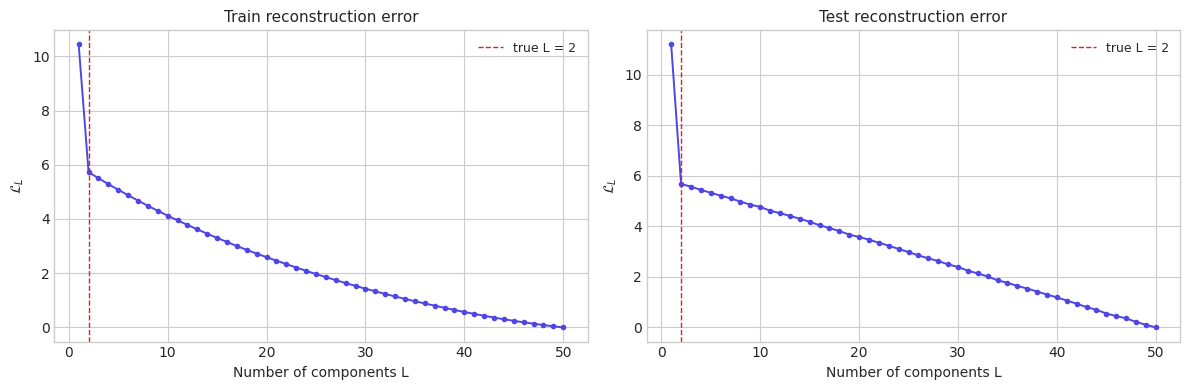

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, err, title in [(axes[0], err_train, 'Train reconstruction error'),
                        (axes[1], err_test, 'Test reconstruction error')]:
    ax.plot(Ls, err, '-o', color='#4f46e5', markersize=3, lw=1.4)
    ax.axvline(L_true, color='#d62728', ls='--', lw=1, label=f'true L = {L_true}')
    ax.set_xlabel('Number of components L')
    ax.set_ylabel(r'$\mathcal{L}_L$')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)

plt.tight_layout(); plt.show()

### 7.2 Scree plot and fraction of variance explained (Section 20.1.4.2)

The **scree plot** displays the eigenvalues themselves in decreasing order. The **fraction of variance explained** integrates them: $F_L = \sum_{j \le L} \lambda_j / \sum_j \lambda_j$. Both reveal the elbow at $L = 2$.

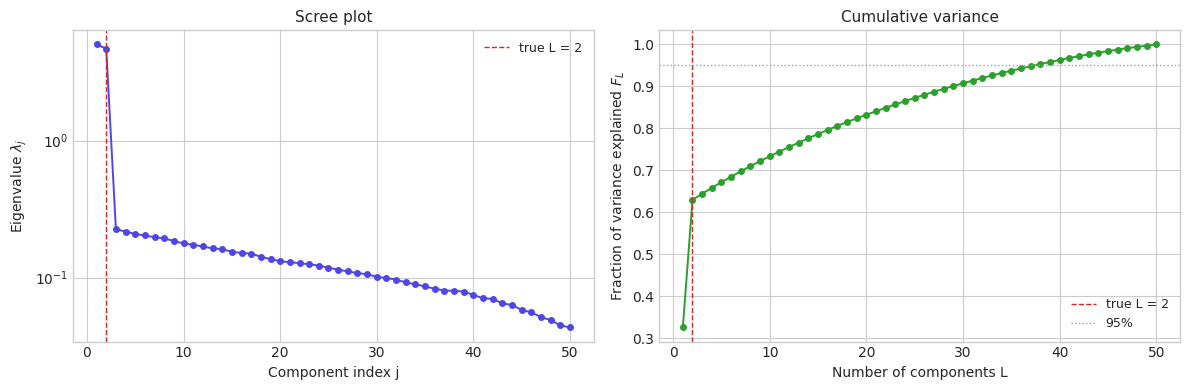

F_1 = 0.326,  F_2 = 0.630,  F_3 = 0.644


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(Ls, evals_full, '-o', color='#4f46e5', markersize=4, lw=1.4)
ax.axvline(L_true, color='#d62728', ls='--', lw=1, label=f'true L = {L_true}')
ax.set_xlabel('Component index j')
ax.set_ylabel(r'Eigenvalue $\lambda_j$')
ax.set_title('Scree plot', fontsize=11)
ax.set_yscale('log')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(Ls, fve, '-o', color='#2ca02c', markersize=4, lw=1.4)
ax.axvline(L_true, color='#d62728', ls='--', lw=1, label=f'true L = {L_true}')
ax.axhline(0.95, color='#94a3b8', ls=':', lw=1, label='95%')
ax.set_xlabel('Number of components L')
ax.set_ylabel(r'Fraction of variance explained $F_L$')
ax.set_title('Cumulative variance', fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout(); plt.show()

print(f'F_1 = {fve[0]:.3f},  F_2 = {fve[1]:.3f},  F_3 = {fve[2]:.3f}')

### 7.3 Profile likelihood (Section 20.1.4.3)

An automated way to detect the elbow: model the eigenvalues as drawn from one Gaussian for $k \le L$ and another for $k > L$, with a shared variance $\sigma^2$ (Eq. 20.28–20.31). The maximum profile log-likelihood pinpoints the change-point.

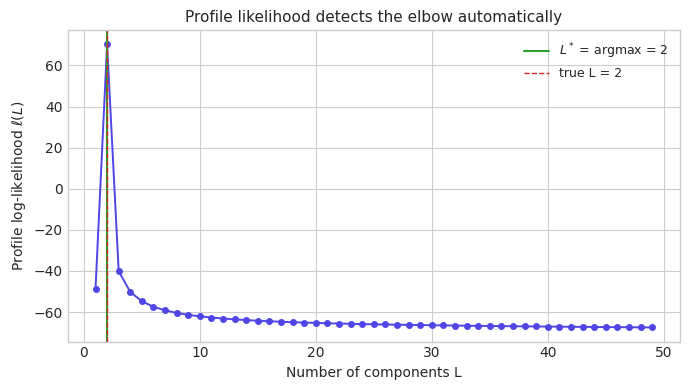

Profile-likelihood estimate: L* = 2
True latent dimensionality:  L  = 2


In [13]:
def profile_log_likelihood(eigs):
    """Profile log-likelihood change-point model on eigenvalue sequence (Eq. 20.28-20.31)."""
    K = len(eigs)
    ll = np.full(K, -np.inf)
    # L ranges from 1 .. K-1 (need at least 1 point in each regime)
    for L_ in range(1, K):
        left, right = eigs[:L_], eigs[L_:]
        mu1 = left.mean()
        mu2 = right.mean()
        ss = ((left - mu1) ** 2).sum() + ((right - mu2) ** 2).sum()
        sigma2 = ss / K
        if sigma2 <= 0:
            continue
        sigma = np.sqrt(sigma2)
        ll[L_-1] = (norm.logpdf(left, mu1, sigma).sum()
                    + norm.logpdf(right, mu2, sigma).sum())
    return ll

ll = profile_log_likelihood(evals_full)
L_star = int(np.argmax(ll)) + 1

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(Ls, ll, '-o', color='#4f46e5', markersize=4, lw=1.4)
ax.axvline(L_star, color='#2ca02c', ls='-', lw=1.5, label=f'$L^*$ = argmax = {L_star}')
ax.axvline(L_true, color='#d62728', ls='--', lw=1, label=f'true L = {L_true}')
ax.set_xlabel('Number of components L')
ax.set_ylabel(r'Profile log-likelihood $\ell(L)$')
ax.set_title('Profile likelihood detects the elbow automatically', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f'Profile-likelihood estimate: L* = {L_star}')
print(f'True latent dimensionality:  L  = {L_true}')

## Summary

- **Reconstruction = variance**: minimising squared reconstruction error and maximising projected variance produce the same orthogonal directions — the eigenvectors of $\hat{\boldsymbol{\Sigma}}$, ordered by eigenvalue.
- **Two implementations**: eigendecomposition of the $D \times D$ covariance matrix vs SVD of the $N \times D$ data matrix; numerically equivalent, with $\lambda_k = s_k^2 / N$.
- **Always think about scale**: PCA on the correlation matrix (i.e. standardised features) is usually safer than the raw covariance matrix.
- **Choosing $L$**: test reconstruction error keeps falling, but the scree plot and profile-likelihood both correctly identify the elbow at the true latent dimensionality.

Applied to single-cell expression data, PCA distils 50 co-regulated genes into two interpretable latent factors that separate growth, stress, and quiescent populations — the linear, deterministic foundation that probabilistic PCA (Section 20.2.2) and nonlinear methods (autoencoders, t-SNE, UMAP) build on.